In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb

#### Data Import


In [2]:
df = pd.read_csv('../data/deliveries.csv')
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [3]:
df.shape

(260920, 17)

In [4]:
df.info

<bound method DataFrame.info of         match_id  inning           batting_team                 bowling_team  \
0         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
1         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
2         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
3         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
4         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
...          ...     ...                    ...                          ...   
260915   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260916   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260917   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260918   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260919   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   

       

# Data Preprocessing

##### Runs Calc conceded by bowlers

In [ ]:
# we are gonna create a new column showing the runs conceded by a bowler(byes,legbyes are extra)
df['bowler_runs'] = df.apply(
    lambda x: x['total_runs'] if x['extras_type'] not in ['legbyes', 'byes', 'penalty'] else x['batsman_runs'], 
    axis=1
)

##### Legal Delivery calculation

In [7]:
# we are gonna create a new column tracking legal deliveries(count of balls bowled is important)
df['is_legal'] = df['extras_type'].apply(lambda x: 0 if x in ['wides', 'noballs'] else 1)

## Filtering
###### Filtering the overs that we need(0-5 && 16 - 19)

##### Power Play Stats

In [16]:
pp_df = df[df['over'] < 6].copy()
pp_stats = pp_df.groupby('bowler').agg(
    pp_runs=('bowler_runs', 'sum'),
    pp_legal_balls=('is_legal', 'sum')
).reset_index()

pp_stats['pp_overs'] = pp_stats.apply(lambda x: x['pp_legal_balls'] / 6, axis=1)
pp_stats.head(10)

,bowler,pp_runs,pp_legal_balls,pp_overs
0,A Ashish Reddy,20,6,1.000000
1,A Badoni,0,1,0.166667
2,A Chandila,137,144,24.000000
3,A Choudhary,46,36,6.000000
4,A Dananjaya,12,6,1.000000
5,A Flintoff,21,12,2.000000
6,A Kamboj,61,30,5.000000
7,A Kumble,88,108,18.000000
8,A Mishra,172,138,23.000000
9,A Mithun,103,66,11.000000


##### Death Over Stats

In [17]:
death_df = df[df['over'] >= 15].copy()
death_stats = death_df.groupby('bowler').agg(
    death_runs=('bowler_runs', 'sum'),
    death_legal_balls=('is_legal', 'sum')
).reset_index()

death_stats['death_overs'] = death_stats.apply(lambda x: x['death_legal_balls'] / 6, axis=1)


death_stats.head(10)

,bowler,death_runs,death_legal_balls,death_overs
0,A Ashish Reddy,167,101,16.833333
1,A Badoni,6,6,1.000000
2,A Chandila,6,6,1.000000
3,A Choudhary,40,24,4.000000
4,A Flintoff,58,24,4.000000
5,A Kumble,212,167,27.833333
6,A Mishra,823,521,86.833333
7,A Mithun,154,78,13.000000
8,A Nehra,778,527,87.833333
9,A Nel,8,6,1.000000


### Join Data Set and Filtering

##### Merge It

In [18]:
merged = pd.merge(pp_stats, death_stats, on='bowler', how='inner')
merged.head()

,bowler,pp_runs,pp_legal_balls,pp_overs,death_runs,death_legal_balls,death_overs
0,A Ashish Reddy,20,6,1.000000,167,101,16.833333
1,A Badoni,0,1,0.166667,6,6,1.000000
2,A Chandila,137,144,24.000000,6,6,1.000000
3,A Choudhary,46,36,6.000000,40,24,4.000000
4,A Flintoff,21,12,2.000000,58,24,4.000000


##### Filter top 10 bowlers having min 20 overs

In [20]:
new_df = merged[(merged['pp_overs']>=20) & (merged['death_overs']>=20)]
new_df.head()

,bowler,pp_runs,pp_legal_balls,pp_overs,death_runs,death_legal_balls,death_overs
6,A Mishra,172,138,23.000000,823,521,86.833333
8,A Nehra,1366,1093,182.166667,778,527,87.833333
10,A Nortje,571,426,71.000000,701,422,70.333333
11,A Singh,295,264,44.000000,268,161,26.833333
18,AB Agarkar,285,180,30.000000,306,182,30.333333


In [24]:
new_df['pp_economy'] = new_df.apply(lambda x: x['pp_runs']/x['pp_overs'], axis= 1)
new_df['death_economy'] = new_df.apply(lambda x: x['death_runs']/x['death_overs'], axis= 1)
new_df.head()

,bowler,pp_runs,pp_legal_balls,pp_overs,death_runs,death_legal_balls,death_overs,pp_economy,death_economy
6,A Mishra,172,138,23.000000,823,521,86.833333,7.478261,9.477927
8,A Nehra,1366,1093,182.166667,778,527,87.833333,7.498628,8.857685
10,A Nortje,571,426,71.000000,701,422,70.333333,8.042254,9.966825
11,A Singh,295,264,44.000000,268,161,26.833333,6.704545,9.987578
18,AB Agarkar,285,180,30.000000,306,182,30.333333,9.500000,10.087912


In [ ]:
top_10_pp = new_df.sort_values('pp_economy').head(10)
top_10_pp

,bowler,pp_runs,pp_legal_balls,pp_overs,death_runs,death_legal_balls,death_overs,pp_economy,death_economy
139,JC Archer,379,396,66.000000,583,371,61.833333,5.742424,9.428571
321,SL Malinga,1159,1111,185.166667,1464,1117,186.166667,6.259226,7.863921
105,DW Steyn,1199,1140,190.000000,877,634,105.666667,6.310526,8.299685
99,DP Nannes,360,342,57.000000,304,208,34.666667,6.315789,8.769231
56,B Kumar,2293,2153,358.833333,2074,1353,225.500000,6.390153,9.197339
284,RJ Harris,456,426,71.000000,424,274,45.666667,6.422535,9.284672
203,M Muralitharan,159,148,24.666667,373,275,45.833333,6.445946,8.138182
71,C Sakariya,203,186,31.000000,235,126,21.000000,6.548387,11.190476
147,JJ Bumrah,1159,1054,175.666667,1723,1247,207.833333,6.597723,8.290297
253,P Kumar,1754,1572,262.000000,1032,592,98.666667,6.694656,10.459459


In [26]:
top_10_death = new_df.sort_values('death_economy').head(10)
top_10_death

,bowler,pp_runs,pp_legal_balls,pp_overs,death_runs,death_legal_balls,death_overs,pp_economy,death_economy
328,SP Narine,1059,924,154.000000,1260,1021,170.166667,6.876623,7.404505
88,DE Bollinger,386,324,54.000000,292,234,39.000000,7.148148,7.487179
321,SL Malinga,1159,1111,185.166667,1464,1117,186.166667,6.259226,7.863921
170,KH Pandya,657,510,85.000000,235,178,29.666667,7.729412,7.921348
201,M Kartik,208,179,29.833333,206,154,25.666667,6.972067,8.025974
292,Rashid Khan,429,331,55.166667,692,516,86.000000,7.776435,8.046512
266,R Ashwin,1368,1198,199.666667,807,595,99.166667,6.851419,8.137815
203,M Muralitharan,159,148,24.666667,373,275,45.833333,6.445946,8.138182
335,SW Tait,294,228,38.000000,207,150,25.000000,7.736842,8.280000
147,JJ Bumrah,1159,1054,175.666667,1723,1247,207.833333,6.597723,8.290297


## Visualisation

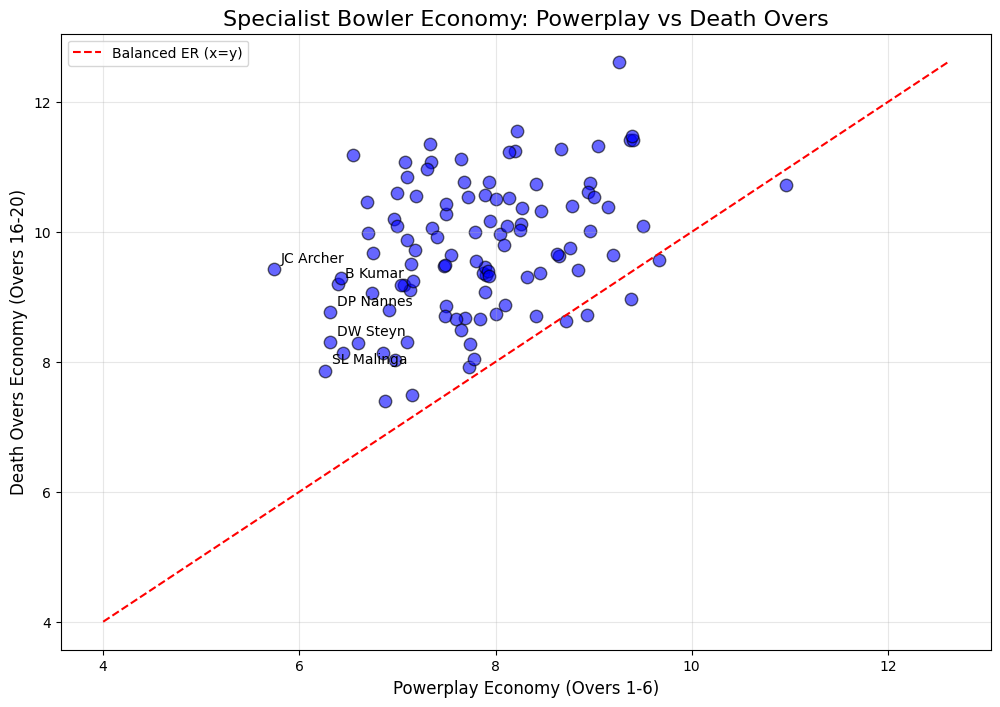

In [27]:
plt.figure(figsize=(12, 8))
plt.scatter(new_df['pp_economy'], new_df['death_economy'], 
            alpha=0.6, c='blue', edgecolors='k', s=80)

# Diagonal reference line x=y
limit = max(new_df['pp_economy'].max(), new_df['death_economy'].max())
plt.plot([4, limit], [4, limit], 'r--', label='Balanced ER (x=y)')

# Labeling some key performers
for i, row in top_10_pp.head(5).iterrows():
    plt.annotate(row['bowler'], (row['pp_economy'], row['death_economy']), 
                 xytext=(5, 5), textcoords='offset points')

plt.title('Specialist Bowler Economy: Powerplay vs Death Overs', fontsize=16)
plt.xlabel('Powerplay Economy (Overs 1-6)', fontsize=12)
plt.ylabel('Death Overs Economy (Overs 16-20)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('bowler_economy_scatter.png')
plt.show()